In [1]:
import pandas as pd

In [3]:
YPFEstado = pd.read_excel("C:/Users/CRIS/Documents/Big Data/Big Data Grupo 19/Presentación/Estado YPF RR.xlsx")
YPFPrivado = pd.read_excel("C:/Users/CRIS/Documents/Big Data/Big Data Grupo 19/Presentación/Privado YPF RR.xlsx")

In [5]:
YPFPrivado = YPFPrivado.rename( columns={
    "año": "Año",
    })
YPFEstado = YPFEstado.rename( columns={
    "Patrimonio neto": "Patrimonio Neto",
    "Resultados netos": "Resultados Netos"
})

In [7]:
YPF = pd.concat([YPFPrivado, YPFEstado])

In [9]:
YPF["Año"] = (YPF["Año"].astype(int))

In [21]:
YPF["Costos"] = YPF["Costos"].abs()

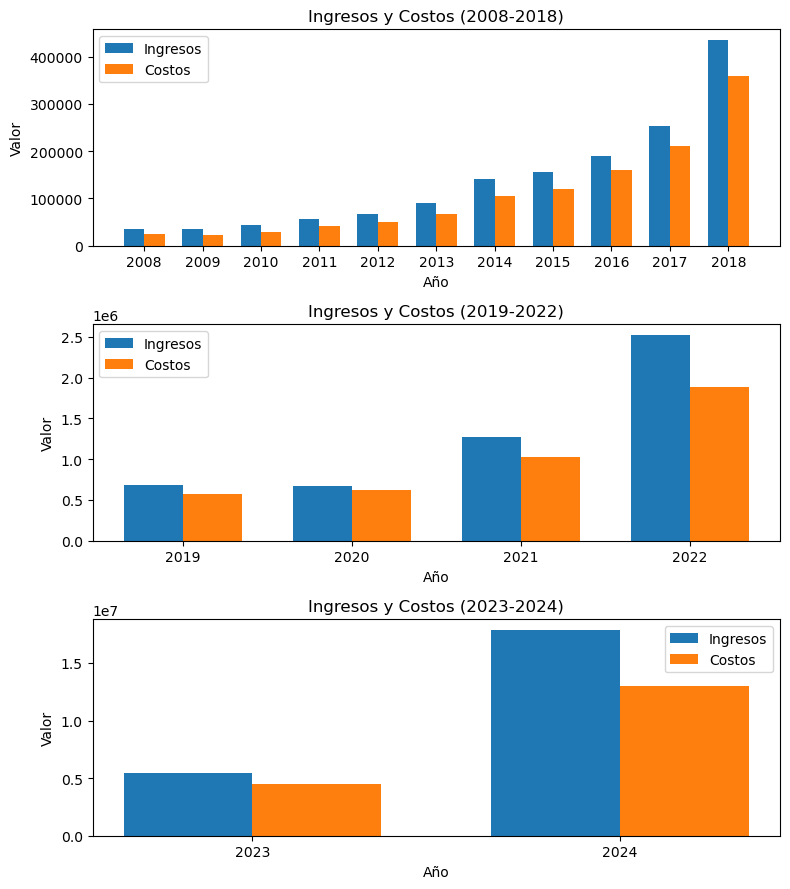

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Filtra los datos para cada rango de años
df_2008_2018 = YPF[(YPF['Año'] >= 2008) & (YPF['Año'] <= 2018)]
df_2019_2022 = YPF[(YPF['Año'] >= 2019) & (YPF['Año'] <= 2022)]
df_2023_2024 = YPF[(YPF['Año'] >= 2023) & (YPF['Año'] <= 2024)]

# Crea un gráfico de barras para cada rango de años
fig, axs = plt.subplots(3, figsize=(8, 9))

bar_width = 0.35
x1 = np.arange(len(df_2008_2018['Año']))
x2 = np.arange(len(df_2019_2022['Año']))
x3 = np.arange(len(df_2023_2024['Año']))

axs[0].bar(x1 - bar_width/2, df_2008_2018['Ingresos'], bar_width, label='Ingresos')
axs[0].bar(x1 + bar_width/2, df_2008_2018['Costos'].abs(), bar_width, label='Costos')
axs[0].set_xticks(x1)
axs[0].set_xticklabels(df_2008_2018['Año'])
axs[0].set_title('Ingresos y Costos (2008-2018)')
axs[0].set_xlabel('Año')
axs[0].set_ylabel('Valor')
axs[0].legend()

axs[1].bar(x2 - bar_width/2, df_2019_2022['Ingresos'], bar_width, label='Ingresos')
axs[1].bar(x2 + bar_width/2, df_2019_2022['Costos'].abs(), bar_width, label='Costos')
axs[1].set_xticks(x2)
axs[1].set_xticklabels(df_2019_2022['Año'])
axs[1].set_title('Ingresos y Costos (2019-2022)')
axs[1].set_xlabel('Año')
axs[1].set_ylabel('Valor')
axs[1].legend()

axs[2].bar(x3 - bar_width/2, df_2023_2024['Ingresos'], bar_width, label='Ingresos')
axs[2].bar(x3 + bar_width/2, df_2023_2024['Costos'].abs(), bar_width, label='Costos')
axs[2].set_xticks(x3)
axs[2].set_xticklabels(df_2023_2024['Año'])
axs[2].set_title('Ingresos y Costos (2023-2024)')
axs[2].set_xlabel('Año')
axs[2].set_ylabel('Valor')
axs[2].legend()

plt.tight_layout()
plt.show()

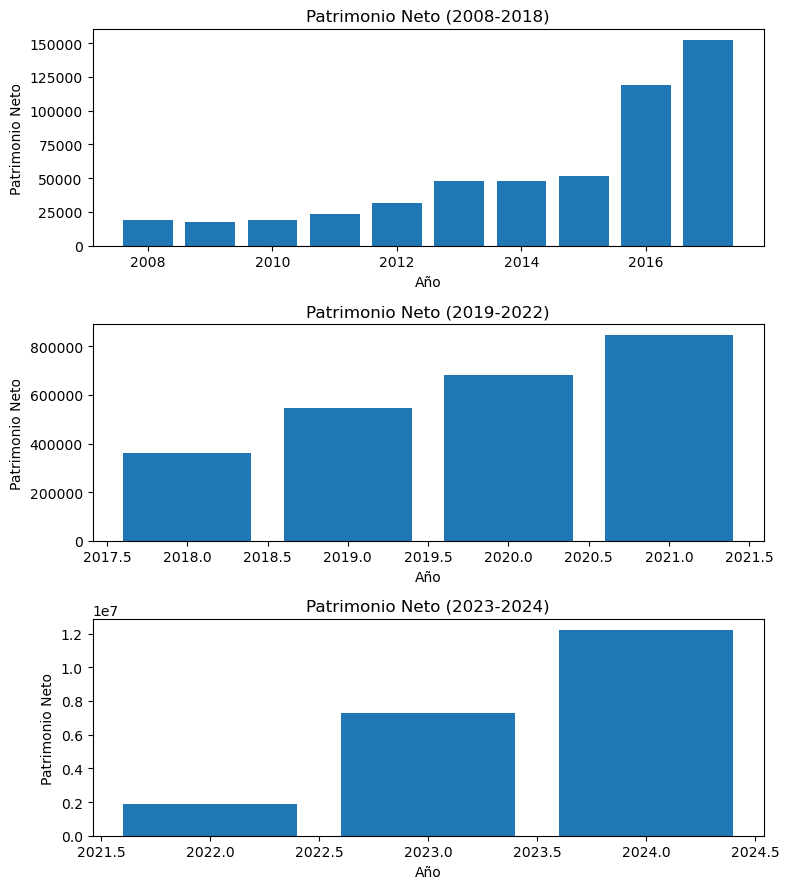

In [47]:
import matplotlib.pyplot as plt

# Filtra los datos para cada rango de años
d_2008_2017 = YPF[(YPF['Año'] >= 2008) & (YPF['Año'] <= 2017)]
d_2018_2021 = YPF[(YPF['Año'] >= 2018) & (YPF['Año'] <= 2021)]
d_2022_2024 = YPF[(YPF['Año'] >= 2022) & (YPF['Año'] <= 2024)]

# Crea un gráfico de barras para cada rango de años
fig, axs = plt.subplots(3, figsize=(8, 9))

axs[0].bar(d_2008_2017['Año'], d_2008_2017['Patrimonio Neto'])
axs[0].set_title('Patrimonio Neto (2008-2018)')
axs[0].set_xlabel('Año')
axs[0].set_ylabel('Patrimonio Neto')

axs[1].bar(d_2018_2021['Año'], d_2018_2021['Patrimonio Neto'])
axs[1].set_title('Patrimonio Neto (2019-2022)')
axs[1].set_xlabel('Año')
axs[1].set_ylabel('Patrimonio Neto')

axs[2].bar(d_2022_2024['Año'], d_2022_2024['Patrimonio Neto'])
axs[2].set_title('Patrimonio Neto (2023-2024)')
axs[2].set_xlabel('Año')
axs[2].set_ylabel('Patrimonio Neto')

plt.tight_layout()
plt.show()

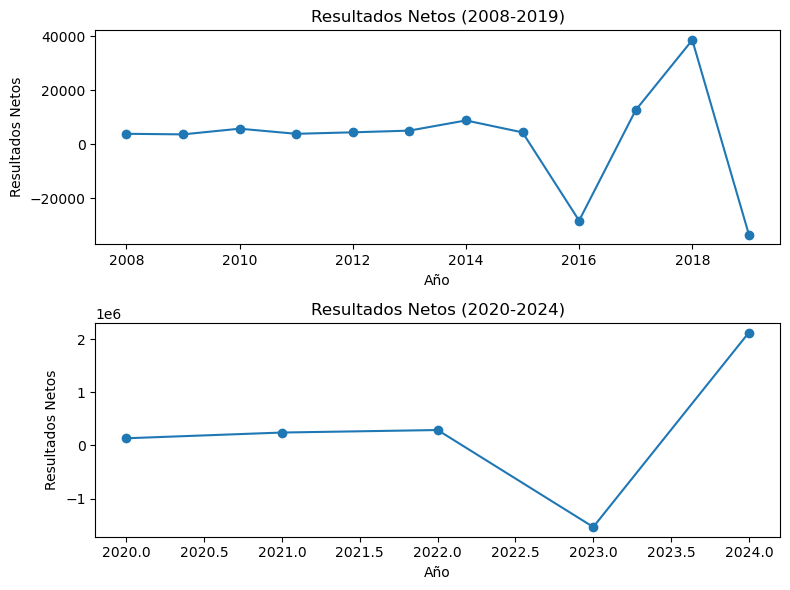

In [51]:
# Filtra los datos para cada rango de años
dx_2008_2019 = YPF[(YPF['Año'] >= 2008) & (YPF['Año'] <= 2019)]
dx_2020_2024 = YPF[(YPF['Año'] >= 2020) & (YPF['Año'] <= 2024)]

# Crea un gráfico de línea para cada rango de años
fig, axs = plt.subplots(2, figsize=(8, 6))

axs[0].plot(dx_2008_2019['Año'], dx_2008_2019['Resultados Netos'], marker='o')
axs[0].set_title('Resultados Netos (2008-2019)')
axs[0].set_xlabel('Año')
axs[0].set_ylabel('Resultados Netos')

axs[1].plot(dx_2020_2024['Año'], dx_2020_2024['Resultados Netos'], marker='o')
axs[1].set_title('Resultados Netos (2020-2024)')
axs[1].set_xlabel('Año')
axs[1].set_ylabel('Resultados Netos')

plt.tight_layout()
plt.show()

In [57]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Selecciona las columnas de interés
df = YPF[['Año', 'Activos', 'Pasivos', 'Patrimonio Neto', 'Ingresos', 'Costos', 'Resultados Netos']]

# Define las variables independientes (X) y la variable dependiente (y)
X = df[['Activos', 'Pasivos', 'Patrimonio Neto', 'Ingresos', 'Costos']]
y = df['Resultados Netos']

# Realiza PCA para reducir la dimensionalidad
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Crea un nuevo DataFrame con las componentes principales y la columna 'Años'
df_pca = pd.DataFrame({'Componente 1': X_pca[:, 0], 'Componente 2': X_pca[:, 1], 'Año': df['Año'].values, 'Resultados Netos': df['Resultados Netos'].values})

# Define las variables independientes (X) y la variable dependiente (y) para la regresión
X_reg = df_pca[['Año', 'Componente 1', 'Componente 2']]
y_reg = df_pca['Resultados Netos']

# Divide los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Crea y entrena el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Realiza predicciones y evalúa el modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse}')

# Puedes utilizar el modelo para hacer predicciones con nuevos datos
nuevo_data = pd.DataFrame({'Año': [2025], 'Componente 1': [10], 'Componente 2': [5]})
nuevo_pred = model.predict(nuevo_data)
print(f'Predicción para 2025: {nuevo_pred[0]}')

MSE: 1292568831584.7488
Predicción para 2025: 216531.64413361996


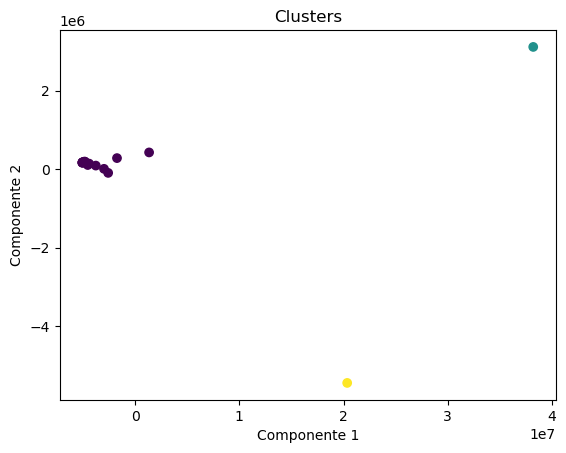

         Componente 1  Componente 2
Cluster                            
0       -3.903970e+06  1.557479e+05
1        3.820842e+07  3.112173e+06
2        2.035113e+07 -5.448391e+06


In [59]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Selecciona las columnas de interés
df = YPF[['Año', 'Activos', 'Pasivos', 'Patrimonio Neto', 'Ingresos', 'Costos', 'Resultados Netos']]

# Define las variables independientes (X)
X = df[['Activos', 'Pasivos', 'Patrimonio Neto', 'Ingresos', 'Costos', 'Resultados Netos']]

# Realiza PCA para reducir la dimensionalidad
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Crea un nuevo DataFrame con las componentes principales
df_pca = pd.DataFrame(X_pca, columns=['Componente 1', 'Componente 2'])

# Realiza clustering con K-Means
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_pca)
labels = kmeans.labels_

# Agrega los labels de clustering al DataFrame
df_pca['Cluster'] = labels

# Visualiza los clusters
plt.scatter(df_pca['Componente 1'], df_pca['Componente 2'], c=df_pca['Cluster'])
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Clusters')
plt.show()

# Puedes analizar los clusters para ver qué características tienen en común
print(df_pca.groupby('Cluster').mean())

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error

# Selecciona las columnas de interés
df = YPF[['Año', 'Activos', 'Pasivos', 'Patrimonio Neto', 'Ingresos', 'Costos', 'Resultados Netos']]

# Define las variables independientes (X) y la variable dependiente (y)
X = df[['Activos', 'Pasivos', 'Patrimonio Neto', 'Ingresos', 'Costos']]
y = df['Resultados Netos']

# Divide los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regresión LASSO
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f'MSE LASSO: {mse_lasso}')

# Regresión Ridge
ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f'MSE Ridge: {mse_ridge}')

MSE LASSO: 1703925723507.928
MSE Ridge: 1265086823937.9875


C:\Users\CRIS\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.336e+10, tolerance: 4.065e+08
  model = cd_fast.enet_coordinate_descent(
C:\Users\CRIS\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.26638e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
